In [3]:
cd ..

c:\Users\KeckLFC\KeckLFC-main


change direction to : c:\Users\KeckLFC\KeckLFC-main

In [ ]:
import tkinter as tk 
from tkinter import ttk
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import threading
import time
from collections import deque
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

## OSA

In [4]:
from KeckLFC.Hardware.Agilent_86142B import Agilent_86142B

osa = Agilent_86142B()
osa.connect()


2025-11-18 14:20:06.637 | INFO     | Device | Device.py:<module>:61
logger initialized
2025-11-18 14:20:08.157 | INFO     | Agilent 86142B | Device.py:connect:228
Agilent 86142B connected


1

2025-11-18 14:20:10.335 | INFO     | Agilent 86142B | Agilent_86142B.py:Run:164
Agilent 86142B: Spectrum collection RUN (repeat) start.
2025-11-18 14:20:10.707 | INFO     | Agilent 86142B | Agilent_86142B.py:set_wlstart:118
Agilent 86142B: Scan start wavelength set to 1553.00 nm.
2025-11-18 14:20:11.004 | INFO     | Agilent 86142B | Agilent_86142B.py:set_wlstop:127
Agilent 86142B: Scan stop wavelength set to 1567.00 nm.
2025-11-18 14:20:11.243 | INFO     | Agilent 86142B | Agilent_86142B.py:set_reflevel:109
Agilent 86142B: Reference level set to -40.0 dBm.


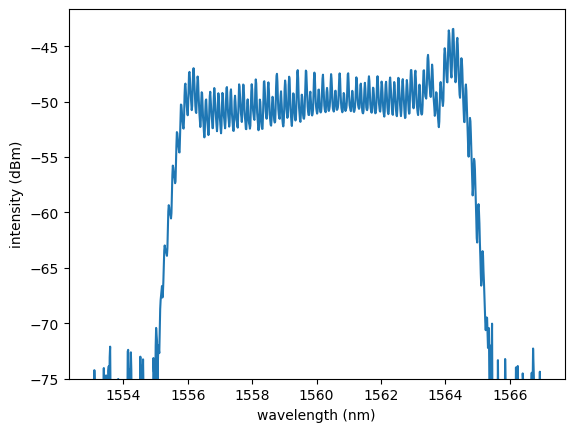

2025-11-18 14:20:12.186 | INFO     | Agilent 86142B | Agilent_86142B.py:get_trace:327
Agilent 86142B: Trace A data is collected and is shown in the plot.


(array([1553.   , 1553.014, 1553.028, ..., 1566.972, 1566.986, 1567.   ],
       dtype=float32),
 array([-79.120125, -79.120125, -78.01427 , ..., -78.95348 , -76.491264,
        -78.95245 ], dtype=float32))

In [5]:
osa.Run()

osa.wlstart=1553
osa.wlstop=1567
osa.reflevel=-40
osa.get_trace('a')

save osa trace

In [ ]:
filedir = r'C:\Users\KeckLFC\Desktop\hispec'
filename = r'\3m_hnlf_for1550_3.63w'
filr = filedir + filename
osa.save_trace('a', filr)

In [ ]:
osa.disconnect()

## EDFA Amonics 27

In [ ]:
from KeckLFC.Hardware.AmonicsEDFA import AmonicsEDFA
amonic27 = AmonicsEDFA(addr=f'ASRL{6}::INSTR', name='Amonics EDFA 27 dBm')
amonic27.connect()
amonic27.printStatus()

In [ ]:
amonic27._setChMode('apc')
amonic27.accCh1Cur='450mw'
amonic27.accCh1Status = 1
amonic27.activation = 1

In [ ]:
amonic27.printStatus()

In [ ]:
amonic27.disconnect()

# RF oscillation source Power supply

In [ ]:
from KeckLFC.Hardware.InstekGPD_4303S import InstekGPD_4303S
rfoscPS = InstekGPD_4303S(addr='ASRL13::INSTR', name='RF oscilator PS, CH2 15V, CH3 1V')
rfoscPS.connect()
rfoscPS.printStatus()

In [ ]:
rfoscPS.Vset2=15
rfoscPS.Iset2=3
rfoscPS.Vset3=0.8
rfoscPS.Iset3=1

rfoscPS.activation = 1

In [ ]:
rfoscPS.disconnect()

## RF amplifier power supply

In [ ]:
from KeckLFC.Hardware.InstekGppDCSupply import InstekGppDCSupply

rfampPS = InstekGppDCSupply(addr=f'ASRL{24}::INSTR', name='RF amplifier PS 30V 4A')
rfampPS.connect()
rfampPS.printStatus()

In [ ]:
rfampPS.Vset1=30
rfampPS.Iset1=4.2
rfampPS.activation1 = 1


In [ ]:
rfampPS.disconnect()

## EDFA Amonics 23 (apmlify the minicomb for pritel)

In [ ]:
from KeckLFC.Hardware.AmonicsEDFA import AmonicsEDFA
amonic23 = AmonicsEDFA(addr=f'ASRL{12}::INSTR', name='Amonics EDFA 23 dBm')
amonic23.connect()
amonic23.printStatus()

In [ ]:
amonic23.accCh1Cur = '80mA'
amonic23.accCh1Status = 1
amonic23.activation = 1

In [ ]:
amonic23.disconnect()

## Arduino, internal lock for pritel and YJ shutter control

In [ ]:
from KeckLFC.Hardware.Arduino_relay import Arduino_relay
arduino = Arduino_relay(addr="COM3")
# print(f'com={i}')
arduino.connect()
arduino.printStatus()

In [ ]:
arduino.reset_relay_latch() # reset to standby, if input is good, then amplifier can be activated

In [ ]:
arduino.shut_YJ()
arduino.pass_YJ()
arduino.get_YJ_info()

In [ ]:
arduino.disconnect()  # disconnect will cause internal relay to off

## Pendulem, the RF frequency counter

In [ ]:
from KeckLFC.Hardware.PendulumCNT90 import PendulumCNT90
pendulem = PendulumCNT90()
pendulem.connect()

In [ ]:
freq=pendulem.measFreq('c')
freq-16e9

# waveshaper

In [ ]:
from KeckLFC.Hardware.Waveshaper import Waveshaper

wsp = Waveshaper()
wsp.connect()

In [ ]:

wsp.set3rdDisper(d2=2.14,d3=0.,center=1559.8) #2.09 -3
wsp.setBandPass(span=5)
wsp.plotStatus()
wsp.writeProfile()

In [ ]:
wsp.disconnect()  # remember to disconnect the Waveshaper before next connection. or will have error and cannot connect again

# servo, usually use IM. Fc is not used. RB will be used in Rb locking

In [ ]:
from KeckLFC.Hardware.SRS_SIM900 import SRS_SIM900, SRS_PIDcontrol_SIM960
srs = SRS_SIM900(addr='GPIB0::2::INSTR')
srs.connect()
servo_FC = SRS_PIDcontrol_SIM960(srs, 1, name='Filter Cavity PDH Lock Servo')
servo_IM = SRS_PIDcontrol_SIM960(srs, 3, name='Minicomb Intensity Lock Servo')
servo_RB = SRS_PIDcontrol_SIM960(srs, 5, name='Rio Laser Fceo Rb spectroscopy Lock Servo')

In [ ]:
servo_IM.manual_output=1.2
time.sleep(1)
print(servo_IM.get_output_voltage() ) 
print(servo_IM.get_measure_input())

In [ ]:
#set limits
servo_IM.output_upperlim = 10
servo_IM.output_lowerlim = -10

# PID gain parameters
servo_IM.prop_gain=-2  #-2 or 4
servo_IM.intg_gain=0.1   #1
servo_IM.outoffset=0.2
servo_IM.set_setpoint(2.2)

In [ ]:
servo_IM.output_mode = 'pid'  #'man'  or 'pid' , unlock/lock

In [ ]:
# scan the vpi
import numpy as np
scan_start = -3
scan_stop =3
num_steps= 100

servo_IM.manual_output_ramp=0.1
servo_IM.manual_output = scan_start

r = servo_IM.manual_sweep(np.linspace(scan_start,scan_stop,num_steps))

servo_IM.manual_output=1.4

In [ ]:
# scan the rf attenuation
import time
import numpy as np
import matplotlib.pyplot as plt

def sweep_voltage(ps, servo,
                  v_start=0.0, v_stop=1.0, num=20,
                  settle_s=0.5,                 # 设点后等待
                  delay_between_points=0.0):    # 每点额外停顿（可为0）
    """
    扫描 ps.Vset3 从 v_start→v_stop（含端点），每点读取一次 servo.get_measure_input()。
    返回形状 (N, 3) 的数组：[设定电压, 测量值, 相对时间s]
    """
    setpoints = np.linspace(v_start, v_stop, num, dtype=float)
    data = np.empty((setpoints.size, 3), dtype=float)
    t0 = time.monotonic()

    # 记录原始设定电压，方便恢复
    try:
        original_v = float(getattr(ps, "Vset3"))
    except Exception:
        original_v = None

    try:
        for i, v in enumerate(setpoints):
            ps.Vset3 = float(v)          # 设定电压
            time.sleep(settle_s)          # 等待稳定

            y = float(servo.get_measure_input())   # 只读一次
            t_rel = time.monotonic() - t0
            data[i] = (v, y, t_rel)

            if delay_between_points > 0:
                time.sleep(delay_between_points)

    except KeyboardInterrupt:
        print("Sweep interrupted by user.")
        data = data[:i]  # 保留已采到的数据
    finally:
        if original_v is not None:
            try:
                ps.Vset3 = original_v
            except Exception:
                pass

    return data

# -------- 使用示例 --------
v_start = 0.0
v_stop  = 2.0
num     = 25
settle  = 0.5

plt_data = sweep_voltage(ps=rfoscPS, servo=servo_IM,
                         v_start=v_start, v_stop=v_stop, num=num,
                         settle_s=settle, delay_between_points=0.0)

plt.figure()
plt.plot(plt_data[:, 0], plt_data[:, 1], marker="o")
plt.xlabel("Vset3 (V)")
plt.ylabel("Measured input (arb.)")
plt.title(f"Sweep Vset3: {v_start} → {v_stop} V, N={num}")
plt.grid(True)
plt.show()

In [ ]:
#adjust the vpi and rf attenuation to get the desired minicomb flatness
import time
servo_IM.manual_output = 1.4
rfoscPS.Vset3=0.85
time.sleep(1)
osa.Run()
time.sleep(1)
osa.get_trace('a')

In [ ]:
# after set to pid, check if locked in 10s
# servo_IM.output_mode = 'pid'  #'man'  or 'pid'
import time
for i in range(20):

    print(servo_IM.get_output_voltage() ) 
    print(servo_IM.get_measure_input())
    time.sleep(0.5)

In [ ]:
servo_IM.printStatus()

## adjust the V_pi and RF atten to see minicomb trace

In [ ]:
import time
servo_IM.manual_output = -0.5 # v_pi you set
rfoscPS.Vset3=0.8
time.sleep(1)
osa.Run()
osa.get_trace('a')
# import time
# time.sleep(1)
# osa.get_trace('a')

## Pritel Amplifier

In [ ]:
from KeckLFC.Hardware.PritelAmp import PritelAmp
ptamp = PritelAmp(addr=f'ASRL{7}::INSTR', name='Pritel Amp')
ptamp.connect()
ptamp.printStatus()

In [ ]:
ptamp.preAmp = 600
ptamp.activation=1

In [ ]:
ptamp.pwrAmp = '0A' # usually 3.8A to 4.2A max

In [ ]:
ptamp.disconnect()

## 2by2 switch

In [ ]:
from KeckLFC.Hardware.Agiltron_2by2_switch import AgiltronSelfAlign22
sw2 = AgiltronSelfAlign22(addr=f'COM{20}')
sw2.connect()
sw2.check_status()

In [ ]:
sw2.set_status(2) # 1 or 2

In [ ]:
sw2.check_status()

In [ ]:
sw2.disconnect()

# HK shutter

In [ ]:
from KeckLFC.Hardware.hk_shutter import hk_shutter
hks = hk_shutter(addr='COM17')   #5,8,11,14,17
hks.connect()

In [ ]:
hks.get_status() # report status 0=shut light, 1=pass light

In [ ]:
hks.set_status(0)

In [ ]:
hks.get_mode() # usually should be in manual mode

# Oscilliscope and Function generater, usually for Rb lock 

In [ ]:
from KeckLFC.Hardware.TDS2024C import TDS2024C
osc = TDS2024C()
osc.connect()

from KeckLFC.Hardware.KeysightFG_33500 import KeysightFG_33500
fg = KeysightFG_33500(addr='USB0::0x0957::0x2807::MY59003824::INSTR', name='Keysight FG 33500')
fg.connect()

fg_pdh = KeysightFG_33500(addr='USB0::0x0957::0x2807::MY62003852::INSTR', name='Keysight FG 33500 for pdh')
fg_pdh.connect()

In [ ]:
fg_pdh.get_channel_parameters(1) #get parameters of channel 1

In [ ]:
osc.get_trace(trace=2)

In [ ]:
#servo_RB.output_mode='man'
fg.set_channel_parameters(channel=1, freq=10, amp=8, offset=0, phase=0)
fg.set_channel_func(1, 'ramp')
fg.set_channel_state(1, 0)
# time.sleep(10)
# trace_x,trace_y=autolock.get_trace(trace = 1)
# plt.plot(trace_x,trace_y)

## RIO laser

In [ ]:
from KeckLFC.Hardware.ORIONLaser import ORIONLaser
rio = ORIONLaser(addr=f'ASRL{14}::INSTR')
rio.connect()
rio.printStatus()

In [ ]:
rio.writeLaserdiodeCur_mA(150)
rio.writeTECsetpoint(19.181+4.1)
rio.printStatus()
osc.get_trace(trace=2)

In [ ]:
rio.writeLaserdiodeCur_mA(150, volatile=False)
#rio.writeTECsetpoint(19.181, volatile=False)
rio.printStatus()

# VOA 1550 2000 1310

In [ ]:
from KeckLFC.Hardware.OZopticsVOA import OZopticsVOA
voa1550 = OZopticsVOA(addr=f'ASRL{15}::INSTR', name='1.55um VOA')
voa1550.connect()
voa1550.printStatus()

In [ ]:
voa1550.atten_db=0 # set attenuation to x dB
voa1550.atten_db  # get current attenuation
voa1550.disconnect()

In [ ]:
from KeckLFC.Hardware.OZopticsVOA import OZopticsVOA
voa2000 = OZopticsVOA(addr=f'ASRL{18}::INSTR', name='2um VOA')
voa2000.connect()
voa2000.printStatus()

In [ ]:
voa2000.atten_db=0 # set attenuation to x dB
voa2000.atten_db  # get current attenuation
voa2000.disconnect()

In [ ]:
from KeckLFC.Hardware.OZopticsVOA import OZopticsVOA
voa1310 = OZopticsVOA(addr=f'ASRL{19}::INSTR', name='1um VOA')
voa1310.connect()
voa1310.printStatus()

In [ ]:
voa1310.atten_db=0 # set attenuation to x dB
voa1310.atten_db  # get current attenuation
voa1310.disconnect()

# TEC of PPLN and Waveguide 

In [ ]:

from KeckLFC.Hardware.TEC_TC720 import TEC_TC720

tec_ppln = TEC_TC720(addr=f'COM{22}', name='PPLN Doubler TEC (TC720)')
tec_ppln.connect()
#tec_ppln.get_mode()

In [ ]:
tec_ppln.get_control_type()
tec_ppln.get_temp()
tec_ppln.set_temp(22)

In [ ]:
tec_ppln.disconnect()

In [ ]:
from KeckLFC.Hardware.TEC_TC720 import TEC_TC720
# tec_PPLN = TEC_TC720(addr='ASRL46::INSTR')
tec_wg = TEC_TC720(addr='COM16', name='Octave Waveguide TEC (TC720)')
tec_wg.connect()

In [ ]:
tec_wg.disconnect()

In [ ]:
# adjust the PPLN temperature to the set point step by step
import time
now_temp=tec_ppln.get_temp()
set_temp=20.1

temp_gap=round(set_temp-now_temp,2)

int_p=int(temp_gap//0.5 )
mod=temp_gap % 0.5
if (int_p>0) or (int_p==0):
    int_p=int_p
else:
    int_p=np.abs(int_p)-1

for i in range(1,int_p+1):
    tec_ppln.set_temp(now_temp+i*0.5)
    time.sleep(4)
    print(tec_ppln.get_temp())

tec_ppln.set_temp(set_temp)
time.sleep(4)


print(tec_ppln.get_temp())


# thermal coupler get temperature from different place

In [ ]:
from KeckLFC.Hardware.USB2408 import USB2408
daq0=USB2408(addr=0)
daq0.connect()
daq1=USB2408(addr=1)
daq1.connect()

In [ ]:
daq0.get_temp_all()
daq1.get_temp_all()